In [1]:
import pathlib
from copy import deepcopy
from tqdm.notebook import tqdm

from matplotlib import cm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from scipy.ndimage import gaussian_filter

from navigoquest.paths import PathDataset, Path
from navigoquest.environments import CohortEnvironment, EnvironmentStore
from navigoquest.utils.config import standard_dirs, LEVELS, METADATA_COLS, AGE_RANGE, ODMAT_WEIGHT_SCALE, ODMAT_WINDOW_SIZE
from navigoquest import format_metric_task_data
from navigoquest.utils.pipelines import load_environment, load_paths_normative, pipeline_compute_features

SAMPLE_RATE = 2.0  # Path datapoint sample rate, per second (baked into this dataset's collection method)
SMOOTH_RATE = 3  # Gaussian smoothing rate in our paper

In [2]:
def linear_extend(values, res):
    # Extend values by resolution by linear interpolation (endpoint inclusive)
    n = values.size
    return np.interp(np.arange(1 + (n-1) * res)/res, np.arange(n), values)

def path_smooth(path, spline_res = 3):
    return np.vstack((gaussian_filter(linear_extend(path[:, 0], spline_res), spline_res * 1.67),
                          gaussian_filter(linear_extend(path[:, 1], spline_res), spline_res * 1.67))).T

def sigmoid_ftn(x):
    return 1/(1+np.exp(-x))

In [3]:
# Settings common over levels
early_stop = np.inf
metric_names = ['duration', 'path_length', 'average_curvature', 'boundary_affinity',
             'frobenius_deviation', 'supremum_deviation', 'conformity', 'vector_conformity']
metric_names_display = ['Dur', 'Len', 'Curv', 'Bdy', 'FDev', 'SDev', 'MCon', 'VCon']

# Directories
dirs = standard_dirs()
paths_dir = dirs['paths']
output_dir = dirs['output']
cohort_env_dir = dirs['env_cohort']

# Load environment
env_store = load_environment(dirs)

# Flags and boundary
flags_all = {lvl: env_store.get(lvl)[0].flags for lvl in [6, 8, 11]}
bdy_all = {lvl: np.load(dirs['env_boundary'] / f"level{lvl:02}_inner_bdry.npy") for lvl in [6, 8, 11]}
bdy_smooth_all = {lvl: path_smooth(bdy_all[lvl]) for lvl in [6, 8, 11]}

# Load the full metrics dataframe
df_filenames = {lvl: f"metrics_level{lvl:02}_gb_2480.csv" for lvl in np.arange(1, 99)}
metrics_all = {lvl: pd.read_csv(output_dir / df_filenames[lvl]) for lvl in LEVELS}

# Restrict to age 50 - 80
metrics_all_5080 = {}
for lvl in [6, 8, 11]:
    metrics_all_5080[lvl] = metrics_all[lvl][(metrics_all[lvl]['age'] >= 50) & (metrics_all[lvl]['age'] <= 80)].reset_index(drop=True)
metrics_all = metrics_all_5080

Loading environment data...
done. 



In [4]:
# Load path datasets (with metadata)
paths_all = {}
for lvl in tqdm(LEVELS):
    print(f"Loading Level {lvl}...")
    dataset = load_paths_normative(lvl, dirs, {'min': 50, 'max': 80}, 
                                   return_dataset_object=True)
    paths_all[lvl] = dataset

  0%|          | 0/5 [00:00<?, ?it/s]

Loading Level 1...
Loading path data...
corrupted data for entry: 68826
corrupted data for entry: 117532
dropping 0 unmatched path(s)
done. 

Loading Level 2...
Loading path data...
corrupted data for entry: 44618
corrupted data for entry: 68024
dropping 0 unmatched path(s)
done. 

Loading Level 6...
Loading path data...
corrupted data for entry: 49304
corrupted data for entry: 49432
dropping 0 unmatched path(s)
done. 

Loading Level 8...
Loading path data...
corrupted data for entry: 33652
corrupted data for entry: 79820
dropping 0 unmatched path(s)
done. 

Loading Level 11...
Loading path data...
corrupted data for entry: 27905
corrupted data for entry: 95579
dropping 0 unmatched path(s)
done. 



In [5]:
# Sort by User ID, Paths
user_id_paths_all = {}
paths_all_sorted = {}
for lvl in [6, 8, 11]:
    user_id_paths = np.array([item.metadata['user_id'] for item in paths_all[lvl].paths])
    user_id_paths_argsort = np.argsort(user_id_paths)
    user_id_paths_all[lvl] = user_id_paths
    paths_all_sorted[lvl] = [paths_all[lvl].paths[idx] for idx in user_id_paths_argsort]

# Sort by User ID, Metrics
user_id_metrics_all = {}
metrics_all_sorted = {}
for lvl in [6, 8, 11]:
    user_id_metrics = metrics_all[lvl]['user_id'].to_numpy()
    user_id_metrics_argsort = np.argsort(user_id_metrics)
    user_id_metrics_all[lvl] = user_id_metrics
    metrics_all_sorted[lvl] = metrics_all[lvl].iloc[user_id_metrics_argsort].reset_index(drop=True)

In [6]:
# Check the User ID match
checker = 0.0
checker_max = 0.0
for lvl in [6, 8, 11]:
    checker += np.all(np.sort(user_id_paths_all[lvl]) == np.sort(user_id_metrics_all[lvl]))
    checker_max += 1

user_id_paths_sorted = {lvl: [item.metadata['user_id'] for item in paths_all_sorted[lvl]] for lvl in [6, 8, 11]}
user_id_metrics_sorted = {lvl: metrics_all_sorted[lvl]['user_id'].tolist() for lvl in [6, 8, 11]}
for lvl in [6, 8, 11]:
    checker += np.all(np.array(user_id_paths_sorted[lvl]) == np.array(user_id_metrics_sorted[lvl]))
    checker_max += 1
    
print(f'User ID checks run: passed {int(checker)}/{int(checker_max)}.')

User ID checks run: passed 6/6.


# Best and worst paths

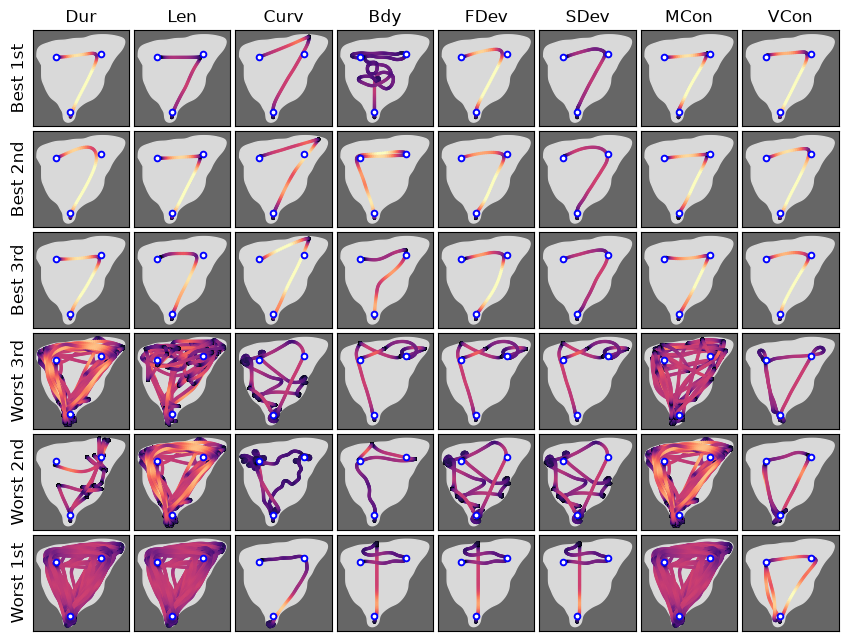

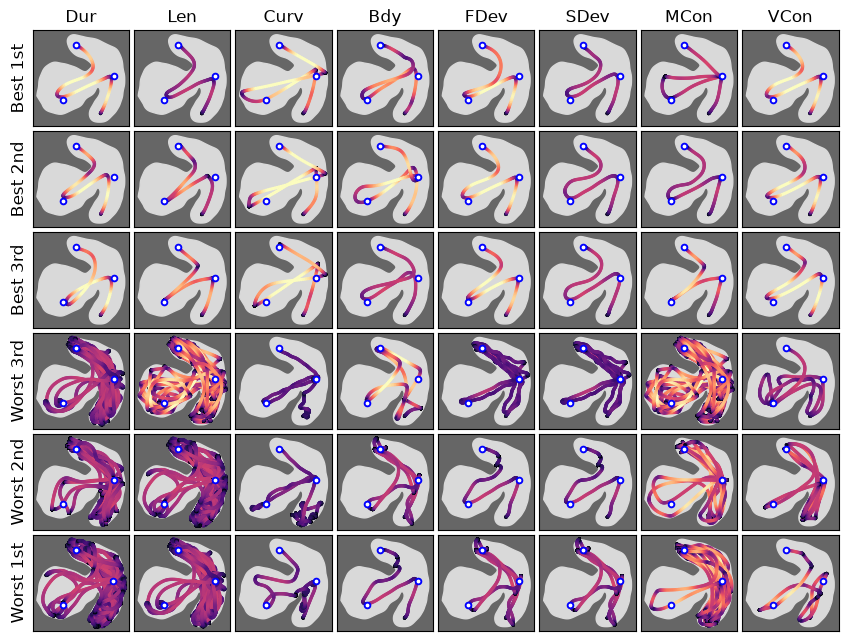

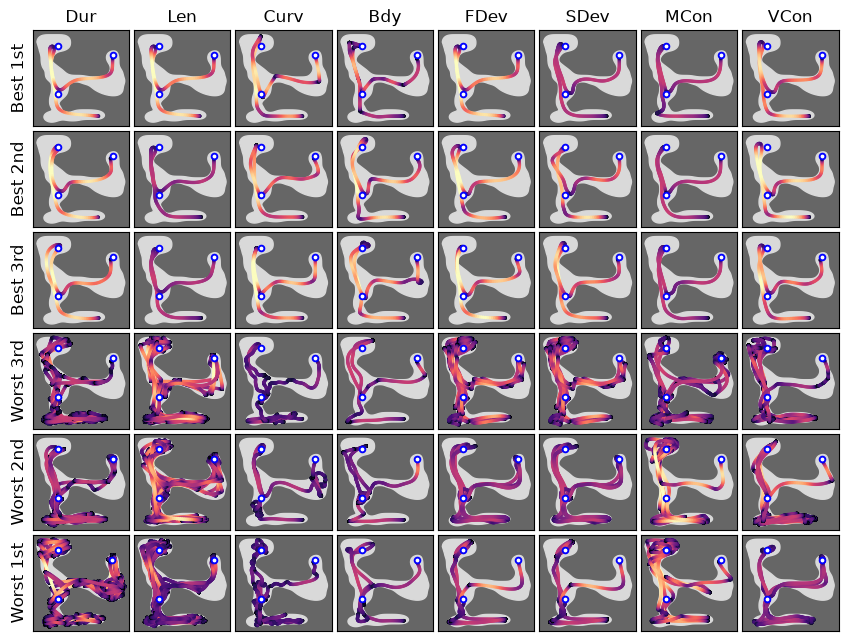

In [7]:
# Setting
best_inds_meta = [0, 1, 2]
worst_inds_meta = [-3, -2, -1]
ncols = len(metric_names)
nrows = len(best_inds_meta) + len(worst_inds_meta)

for lvl in [6, 8, 11]:
    # Figure setting
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows)
    fig.set_size_inches(1.3*ncols, 1.3*nrows)
    plt.subplots_adjust(hspace=0.05, wspace=0.05)

    # Boundary
    color1 = (0.4, 0.4, 0.4, 1) # Background
    color2 = (0.85, 0.85, 0.85, 1) # Inner area
    bdy_now = path_smooth(bdy_all[lvl])
    for i in range(nrows):
        for j in range(ncols):
            ax[i, j].set_facecolor(color=color1)
            ax[i, j].fill(bdy_now[:, 0], bdy_now[:, 1], color = color2, zorder = 0)

    # Paths
    for i, metric_name in enumerate(metric_names):
        # Best and worst indices
        metric_1darr = metrics_all_sorted[lvl][metric_name]
        best_inds = np.argsort(metric_1darr).to_numpy()[best_inds_meta]
        worst_inds = np.argsort(metric_1darr).to_numpy()[worst_inds_meta]

        # Best and worst path
        best_paths = [paths_all_sorted[lvl][idx].smooth_xy for idx in best_inds]
        worst_paths = [paths_all_sorted[lvl][idx].smooth_xy for idx in worst_inds]

        # Velocity
        best_paths_vels = [np.linalg.norm(item[1:] - item[:-1], axis=1) for item in best_paths]
        worst_paths_vels = [np.linalg.norm(item[1:] - item[:-1], axis=1) for item in worst_paths]

        # Plotting
        for j in range(int(nrows/2)):
            ax[j, i].scatter(best_paths[j][:-1, 0], best_paths[j][:-1, 1], c=best_paths_vels[j], cmap='magma', s=2.0, vmin=0, vmax=1)
            ax[j, i].set_xticks([])
            ax[j, i].set_yticks([])

            ax[3+j, i].scatter(worst_paths[j][:-1, 0], worst_paths[j][:-1, 1], c=worst_paths_vels[j], cmap='magma', s=2.0, vmin=0, vmax=1)
            ax[3+j, i].set_xticks([])
            ax[3+j, i].set_yticks([])

    # Flags
    flags_now = flags_all[lvl]
    for i in range(nrows):
        for j in range(ncols):
            ax[i, j].scatter(flags_now[:,0], flags_now[:,1], c='blue', s=20)
            ax[i, j].scatter(flags_now[:,0], flags_now[:,1], c='white', s=3)

    # Side caption
    bestworst_subtext = ['1st', '2nd', '3rd']
    for i in range(int(nrows/2)):
        ax[i, 0].set_ylabel(f'Best {bestworst_subtext[i]}', fontsize=12)
        ax[nrows-1-i, 0].set_ylabel(f'Worst {bestworst_subtext[i]}', fontsize=12)

    # Top caption
    for i in range(ncols):
        ax[0, i].set_title(metric_names_display[i], fontsize=12)

    plt.show()

# Correlation

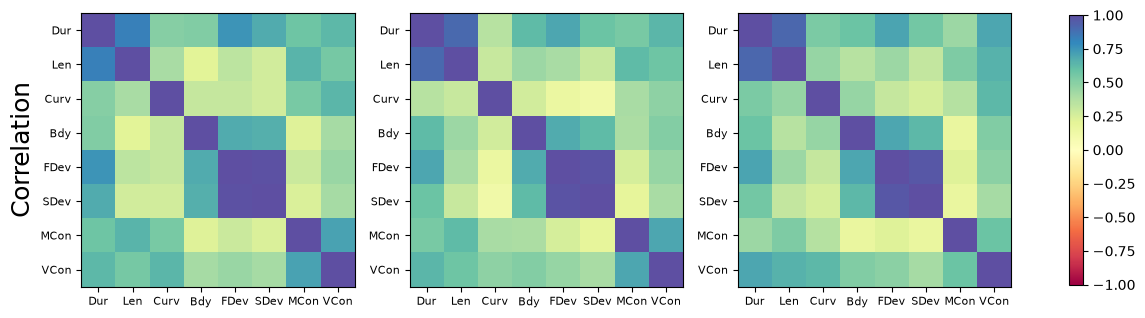

In [8]:
# Compute correlation
corr_matrix_all = {lvl: np.corrcoef(metrics_all_sorted[lvl][metric_names].to_numpy().T) for lvl in [6, 8, 11]}

# Plot
fig, ax = plt.subplots(ncols=3, nrows=1)
fig.set_size_inches(15, 5)
for i, lvl in enumerate([6, 8, 11]):
    im = ax[i].imshow(corr_matrix_all[lvl], vmin=-1, vmax=1, cmap='Spectral')
    ax[i].set_xticks(np.arange(8))
    ax[i].set_yticks(np.arange(8))
    ax[i].set_xticklabels(metric_names_display, fontsize=8)
    ax[i].set_yticklabels(metric_names_display, fontsize=8)
ax[0].set_ylabel(f'Correlation', fontsize=18)
plt.colorbar(im, ax=ax, shrink=0.7)
plt.show()

In [9]:
# Distribution of correlation coefficients (min, max, mean)
corr_flat_all = {lvl: np.sort(corr_matrix_all[lvl].flatten())[:-8] for lvl in [6, 8, 11]}
corr_flat_flat = np.sort(np.array([corr_flat_all[lvl] for lvl in [6, 8, 11]]).flatten())

for lvl in [6, 8, 11]:
    item = corr_flat_all[lvl]
    print(f'Level {lvl}; min, max, mean:')
    print(round(np.min(item), 4), round(np.max(item), 4), round(np.mean(item), 4))

print(f'Concatenated:')
print(round(np.min(corr_flat_flat), 4), round(np.max(corr_flat_flat), 4), round(np.mean(corr_flat_flat), 4))

Level 6; min, max, mean:
0.2061 0.9853 0.5004
Level 8; min, max, mean:
0.1105 0.9777 0.4848
Level 11; min, max, mean:
0.1573 0.9678 0.5011
Concatenated:
0.1105 0.9853 0.4955


# Figure 1

In [10]:
# Mobility field functions
def mobfield(odmat, width, length):
    assert odmat.shape[0] == odmat.shape[1]
    N = odmat.shape[0]
    
    helpvec_x = np.arange(N)%width
    helpvec_y = np.floor(np.arange(N)/width)
    
    mob_x = helpvec_x @ odmat.T - (np.ones(N) @ odmat.T) * helpvec_x
    mob_y = helpvec_y @ odmat.T - (np.ones(N) @ odmat.T) * helpvec_y
    return (mob_x, mob_y)

def plot_mob(odmats, mobs, map_dims, ax, key, fig_scale = 0.1, arrowlen_scale = 5, arrow_scale = 12, auto_limits = True, mob_tol=0.0):
    lvl = key[0]
    (map_width, map_length) = map_dims[lvl]
    # plt.figure().set_size_inches(map_width * fig_scale, map_length * fig_scale)
    ax.set_xticks([])
    ax.set_yticks([])
    if auto_limits:
        ax.set_xlim([0, map_width])
        ax.set_ylim([0, map_length])
    odmat_now = odmats[key[0]][key[1:]].mat

    assert odmat_now.shape[0] == odmat_now.shape[1]
    assert odmat_now.shape[0] == map_width * map_length
    N = map_width * map_length

    mobfield_now = mobs[key]
    mob_x = mobfield_now[0]
    mob_y = mobfield_now[1]
    mob_norm = mob_norms[key]
    mob_maxnorm = np.max(mob_norm)
    for i in range(N):
        pos_x = i % map_width
        pos_y = np.floor(i / map_width)
        if mob_norm[i] > mob_tol:
            # plt.arrow(pos_x, pos_y, 10 * mob_x[i], 10 * mob_y[i], head_width = 0.01, 
                      # color = cm.viridis(mob_norm[i] / mob_maxnorm))
            ax.arrow(pos_x, pos_y, arrowlen_scale * mob_x[i], arrowlen_scale * mob_y[i], 
                      width = 0.01 * arrow_scale, head_width = 0.05 * arrow_scale, 
                      color = cm.Blues(sigmoid_ftn(10 * mob_norm[i] / mob_maxnorm)),
                      alpha = sigmoid_ftn(10 * mob_norm[i] / mob_maxnorm))

In [11]:
# Mobility field computation
odmats_all = {key: env_store.get(key)[0].od_matrices for key in [6, 8, 11]}
# inner_bdy = {key: np.load(dirs['env_boundary'] / f"level{key:02}_inner_bdry.npy") for key in [6, 8, 11]}
# inner_bdy = {key: path_smooth(inner_bdy[key]) for key in [6, 8, 11]}
map_dims = {key: (env_store.get(key)[0].grid_width, env_store.get(key)[0].grid_length) for key in [6, 8, 11]}
mobs = {}
mob_norms = {}
for ind_lvl, item_lvl in enumerate([6, 8, 11]):
    for gender in ['f', 'm']:
        for age in np.arange(50, 80 + 1):
            key = (item_lvl, age, gender)
            odmat_now = odmats_all[key[0]][key[1:]].mat
            mob = mobfield(odmat_now, map_dims[item_lvl][0], map_dims[item_lvl][1])
            mob_norm = np.sqrt(np.power(mob[0], 2) + np.power(mob[1], 2))
            mobs[key] = mob
            mob_norms[key] = mob_norm

In [12]:
idx = 10

path_examples = [paths_all[lvl].paths[idx].xy for lvl in [6, 8, 11]]
path_smooth_examples = [paths_all[lvl].paths[idx].smooth_xy for lvl in [6, 8, 11]]
path_smooth_vel_examples = [np.linalg.norm(item[1:] - item[:-1], axis=1) for item in path_smooth_examples]

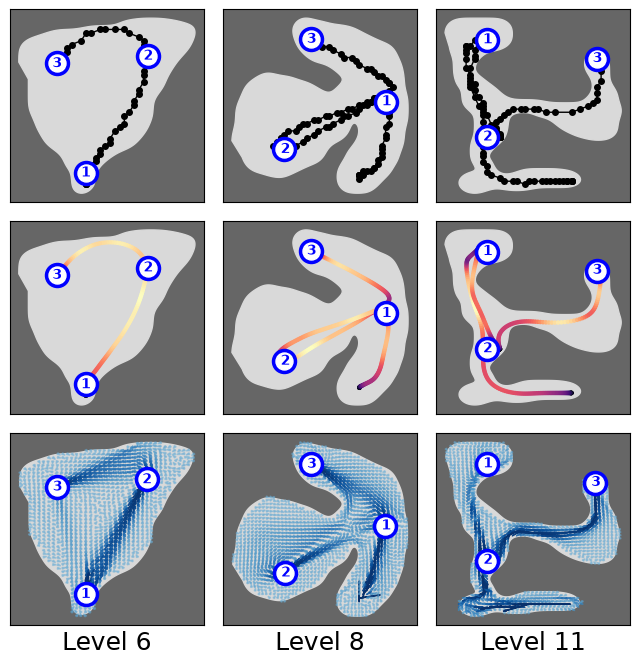

In [13]:
fig, ax = plt.subplots(ncols=3, nrows=3)
fig.set_size_inches(8, 8)
plt.subplots_adjust(wspace=0.1, hspace=0.1)

# Paths plot
for i in range(3):
    ax[0, i].plot(path_examples[i][:-1, 0], path_examples[i][:-1, 1], marker='o', c='black', markersize=4, linewidth=1)
    ax[1, i].scatter(path_smooth_examples[i][:-1, 0], path_smooth_examples[i][:-1, 1], c=path_smooth_vel_examples[i], cmap='magma', s=5)

# Mobility field plot
for i, lvl in enumerate([6, 8, 11]):
    key = (lvl, 60, 'f')
    odmat_now = odmats_all[key[0]][key[1:]].mat
    bdy_pts = bdy_smooth_all[key[0]]
    bdy_pts_looped = np.vstack([bdy_pts, bdy_pts[0]])
    mob = mobfield(odmat_now, map_dims[lvl][0], map_dims[lvl][1])
    mob_norm = np.sqrt(np.power(mob[0], 2) + np.power(mob[1], 2))
    # ax[i, 2].set_title(f'Full path and Field', fontsize=15)
    # ax[2, i].plot(bdy_pts_looped.T[0], bdy_pts_looped.T[1], linewidth = 2, color = 'gray')
    plot_mob(odmats_all, mobs, map_dims, ax[2, i], key, fig_scale = 0.1, arrowlen_scale = 5, arrow_scale = 10, auto_limits=False)
    # ax[i, 2].plot(item_path[:, 0], item_path[:, 1], linewidth=3, c='dodgerblue')

# Boundary
color1 = (0.4, 0.4, 0.4, 1) # Background
color2 = (0.85, 0.85, 0.85, 1) # Inner area
for i in range(3):
    for j in range(3):
        lvl = [6, 8, 11][j]
        ax[i, j].set_facecolor(color=color1)
        ax[i, j].fill(bdy_smooth_all[lvl][:, 0], bdy_smooth_all[lvl][:, 1], color = color2, zorder = 0)

# Flags
for i in range(3):
    for j in range(3):
        lvl = [6, 8, 11][j]
        flags_now = flags_all[lvl]
        ax[i, j].scatter(flags_now[:,0], flags_now[:,1], c='blue', s=300, zorder=90)
        ax[i, j].scatter(flags_now[:,0], flags_now[:,1], c='white', s=150, zorder=100)
        for k, flag in enumerate(flags_now):
            ax[i, j].text(flag[0]-1.0, flag[1]-1.0, f'{k+1}', zorder=110, c='blue', weight='bold')

# Ticks and labels
for i in range(3):
    for j in range(3):
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])

for i in range(3):
    lvl = [6, 8, 11][i]
    ax[2, i].set_xlabel(f'Level {lvl}', fontsize=18)

plt.show()

# Mobility field (big)

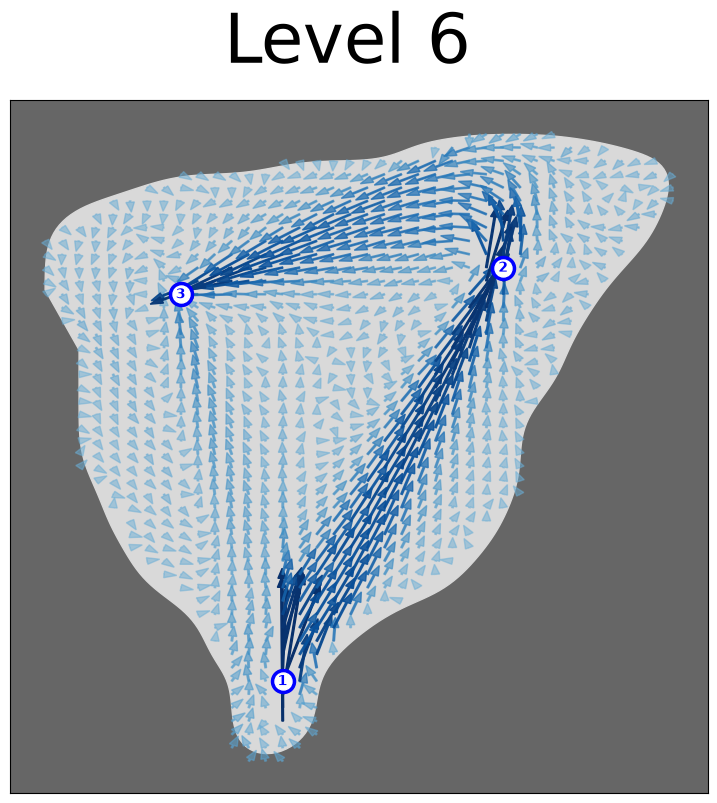

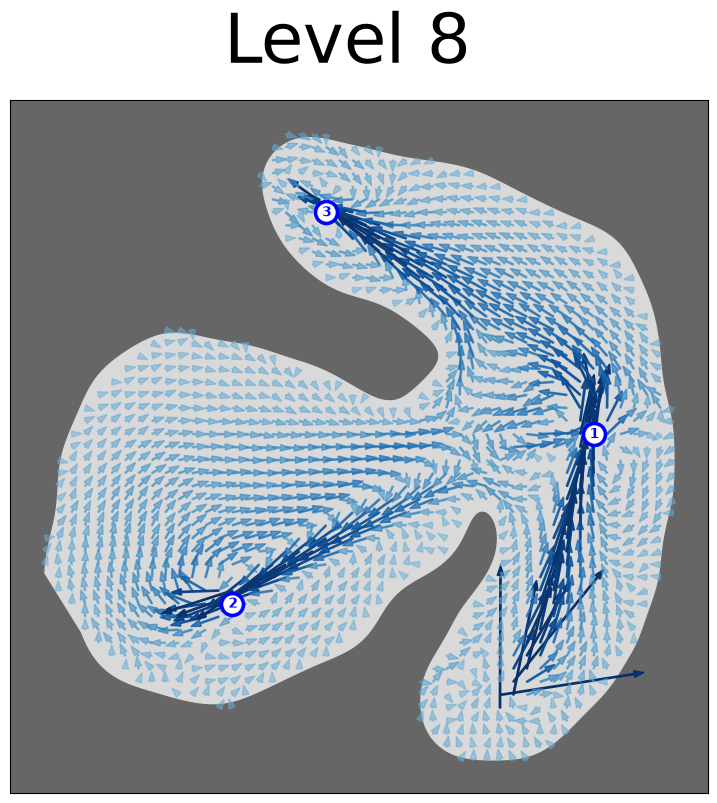

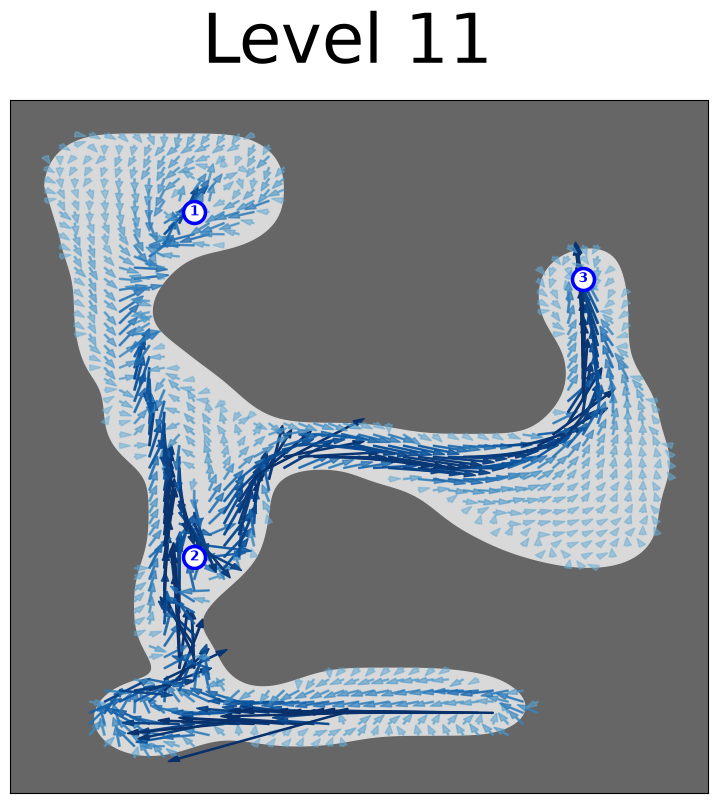

In [14]:
color1 = (0.4, 0.4, 0.4, 1) # Background
color2 = (0.85, 0.85, 0.85, 1) # Inner area

for i, lvl in enumerate([6, 8, 11]):
    fig, ax = plt.subplots()
    fig.set_size_inches(9, 9)

    # Mobility field plot
    key = (lvl, 60, 'f')
    odmat_now = odmats_all[key[0]][key[1:]].mat
    bdy_pts = bdy_smooth_all[key[0]]
    bdy_pts_looped = np.vstack([bdy_pts, bdy_pts[0]])
    mob = mobfield(odmat_now, map_dims[lvl][0], map_dims[lvl][1])
    mob_norm = np.sqrt(np.power(mob[0], 2) + np.power(mob[1], 2))
    plot_mob(odmats_all, mobs, map_dims, ax, key, fig_scale = 0.1, arrowlen_scale = 10, arrow_scale = 10, auto_limits=False)

    # Boundary
    ax.set_facecolor(color=color1)
    ax.fill(bdy_smooth_all[lvl][:, 0], bdy_smooth_all[lvl][:, 1], color = color2, zorder = 0)

    # Flags
    flags_now = flags_all[lvl]
    ax.scatter(flags_now[:,0], flags_now[:,1], c='blue', s=300, zorder=90)
    ax.scatter(flags_now[:,0], flags_now[:,1], c='white', s=150, zorder=100)
    for k, flag in enumerate(flags_now):
        ax.text(flag[0]-0.3, flag[1]-0.3, f'{k+1}', zorder=110, c='blue', weight='bold')

    plt.suptitle(f'Level {lvl}', fontsize=50)
    plt.show()